---
title: Gradient Descent - Machine Learning
date: 2026-07-14 20:00:00
categories: [DATA SCIENCE, MACHINE LEARNING]
tags: [python,matplotlib,sklearn,math]      # TAG names should always be lowercase
image:
 path: /assets/img/posts/2026/07/2025-07-14-Gradient-descent/.png
---



# Introduction

Atualmente estou me especializando em Ciência de Dados, como é uma área que possui diversos assuntos, achei necessário além da especialização buscar novos materiais pela internet, nesse post explicarei o conceito de gradiente descendente, com as minhas palavras e também com as pesquisas feitas.

O gradiente descendente é um método usado em matemática e aprendizado de máquina, para encontrar o mínimo de uma função. A ideia é simples: você começa em um ponto qualquer da função e vai ajustando esse ponto passo a passo, sempre descendo na direção em que a função diminui mais rápido — essa direção é dada pelo gradiente (que indica a inclinação da função).

## Conceitos básicos

Antes de me debruçar diretamente no gradiente descente preciso explicar alguns conceito básicos: **regressão linear e perda**.

1. Regressão linear

É uma técnica estatística usada para encontrar a relação entre variáveis, a regressão linear encontra a relação entre atributos e um rótulo.
Ela pode ser escrita em em equação: y' = ax + b

Onde:
- **a**: é a inclinação da reta.
- **b**: é a interseção de y, onde a reta passa no eixo de x e y.
- **'y**: é o rótulo previsto
- **x**: é a nossa feature, nosso valor de entrada.  


| **X (feature)** | **Y (target)** |
| --- | --- |
| 0.0 | 1.5 |
| 2.5 | 5.2 |
| 5.0 | 12.1 |
| 7.5 | 14.7 |
| 10.0 | 21.2 |


2. Perda  
Utilizamos a perda como uma métrica, para calcular o quão distantes(errados) estamos da previsão do modelo, a diferença da distância entre o valor real e o valor previsto é o valor da nossa perda.

### Gráfico de uma regressão linear


Trazendo o conceito para Machine Learning (ML) podemos reescrever a equação algébrica como sendo: `y' = b + wx`

- **b**: nossa intersecção, é conhecido como viés (também como w0), ele é calculado durante o treinamento.  
- **w**: é o peso, possui o mesmo conceito de inclinação na equação de uma reta, também é calculado durante o treinamento.  
- **x**: é nosso atributo a entrada, a feature.  

Através dessa equação o modelo é treinado, calcula os pesos e viés para produzir o melhor modelo.
No mundo real utilizando mais de um atributo para prevê determinado valor, por exemplo, o gasto de combustível de um carro, podemos usar cilindrada do motor, peso do carro, modelo, aceleração, entre outros. Sendo assim, precisamos inserir esses atributos também no treinamento do modelo, a equação ficaria da seguinte forme:

`y' = b + w1x2 + w2x2 + w3x3 + w4x4 ...`

Assim como um modelo com apenas uma feature, os pesos também serão calculados durante o treinamento.

Abaixo demonstro um gráfico de uma regressão linear, usando somente uma feature, onde os pontos vermelhos são nossos valores reais, as retas verticais mostram a distância (perda) dos valores reais até a reta de regressão onde nosso modelo passa.

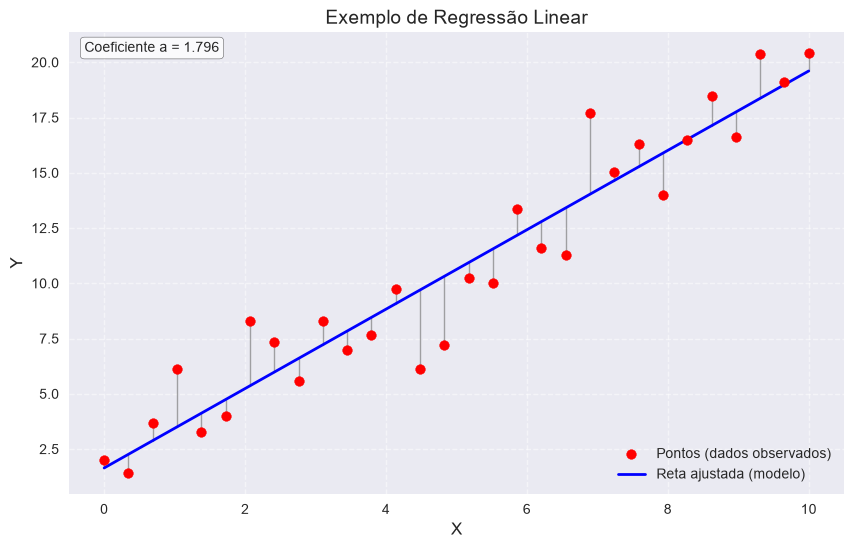

In [7]:
# Exemplo simples de regressão linear para ilustrar perda (resíduos)
# Requisitos: Python 3, numpy, matplotlib
import numpy as np
import matplotlib.pyplot as plt

# --- Gerar dados lineares com ruído ---
np.random.seed(42)                      # reprodutibilidade
x = np.linspace(0, 10, 30)              # eixo X
y_true = 2.0 * x + 1.0                  # relação linear verdadeira
noise = np.random.normal(0, 2.0, x.shape)  # ruído gaussiano
y = y_true + noise                      # observações (pontos próximos à reta)

# --- Ajuste de regressão linear manual (mínimos quadrados) ---
# fórmula: a = cov(x,y)/var(x); b = mean(y) - a*mean(x)
a = np.cov(x, y, bias=True)[0, 1] / np.var(x)
b = np.mean(y) - a * np.mean(x)
y_pred = a * x + b

# --- Plotagem ---
plt.style.use('seaborn-v0_8')           # estilo limpo
fig, ax = plt.subplots(figsize=(10, 6))

# pontos de dados em vermelho
ax.scatter(x, y, color='red', label='Pontos (dados observados)', zorder=3)

# reta ajustada em azul
ax.plot(x, y_pred, color='blue', linewidth=2, label='Reta ajustada (modelo)', zorder=2)

# linhas verticais mostrando resíduos (diferença entre y e y_pred)
for xi, yi, ypi in zip(x, y, y_pred):
    ax.plot([xi, xi], [yi, ypi], color='gray', linewidth=1, alpha=0.7, zorder=1)

# anotações e estilo
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('Exemplo de Regressão Linear', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

textstr = f'Coeficiente a = {a:.3f}'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# mostrar na tela
plt.show()


### Tipos de perdas

A perda não vê direção, apenas mede a sua distância, o símbolo de negativo é removido. Existem diversos tipos de perdas (abaixo a tabela), os principais são:

1. Pegue o valor absoluto da diferença entre o valor real e a previsão.
2. Eleve ao quadrado a diferença entre o valor real e a previsão.

Outros tipos:

| Tipo de perda | Definição |
| --- | --- |
| Erro médio absoluto (MAE) | A média das perdas L1 em um conjunto de N exemplos.| 
| Erro quadrático médio (EQM) | A média das perdas L2 em um conjunto de N exemplos. |
|Raiz do erro quadrático médio (RMSE) | A raiz quadrada do erro quadrático médio (EQM). |

In [21]:
import numpy as np

# Um único valor de entrada
x = 7.8
y_true = 12.0   # valor real

# Parâmetros da regressão linear
w = 2.0
b = 0.5

# Predição
y_pred = b + w * x

# Funções de perda
def mse(y_true, y_pred):
    return (y_true - y_pred) ** 2

def mae(y_true, y_pred):
    return abs(y_true - y_pred)


def perda_simples(y_true, y_pred):
    return y_true - y_pred

# Cálculos
print(f"x = {x:.2f}")
print(f"y_real = {y_true:.2f}")
print(f"y_pred = {y_pred:.2f}")
print(f"Perda simples (diferença): {perda_simples(y_true, y_pred):.2f}")
print(f"MAE (Erro Absoluto Médio): {mae(y_true, y_pred):.2f}")
print(f"MSE (Erro Quadrático Médio): {mse(y_true, y_pred):.2f}")


x = 7.80
y_real = 12.00
y_pred = 16.10
Perda simples (diferença): -4.10
MAE (Erro Absoluto Médio): 4.10
MSE (Erro Quadrático Médio): 16.81
